<!-- NINO26-CABECALHO v1 -->
# 3I — Interpretação integrada da Fase 3

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `3I`  ·  **Hipótese:** HIP0

## Descritivo (por que este notebook existe)
Sintetiza 3A-3H/3K num conjunto de precursores com antecedência e numa leitura cautelosa para 2025/26 — a evidência que entra no parecer do mecanismo.

## Pergunta
Qual conjunto de variáveis explica o aquecimento máximo com antecedência e qual é a leitura prospectiva cautelosa para 2025/26?

## Desafio (hipótese a testar)
A projeção condicional deve ser rotulada como exploratória, com IC largo declarado e sem vazamento de informação futura.

## Metodologia (com referências)
Consolidação dos precursores, antecipação do pico e projeção condicional com validação nested LOO (Cawley & Talbot, 2010; complexidade de ENSO em Timmermann et al., 2018; Cai et al., 2020).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução. A fonte deve ser uma tabela persistida com sidecar e hash do mesmo `run_id`:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_3I01", fase=3, bloco="I",
                 titulo=..., descricao=..., hipotese="HIP0",
                 notebook="notebooks/fase3/3I_interpretacao_integrada.ipynb",
                 run_id=run.run_id,
                 fontes={"<tabela>": tabela_path})   # Path + .manifest.json -> figures/fase3/<codigo>.png + numeric-tables/fase3/<codigo>/
```

| Código | Figura (`figures/fase3/<código>.png`) | Numeric-table (`numeric-tables/fase3/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_3I01` | `Fig_3I01.png` | `Fig_3I01/` | síntese para o parecer |
| `Fig_3I02` | `Fig_3I02.png` | `Fig_3I02/` | antecipação do pico |
| `Fig_3I03` | `Fig_3I03.png` | `Fig_3I03/` | projeção condicional nested |
| `Fig_3I04` | `Fig_3I04.png` | `Fig_3I04/` | galeria de figuras da Fase 3 |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; compatibilidade por `python scripts/validar_figuras.py --strict --allow-render-extraction`; promoção por `python scripts/validar_figuras.py --strict`.

## Contrato científico central

As tabelas abaixo são geradas pelo executor F3 testado. Rótulos de fase/faixa de pico são retrospectivos; previsão usa apenas a tabela rolling-origin. O evento é a unidade independente.


In [1]:
from pathlib import Path
import json, os, subprocess, sys
import pandas as pd
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'pyproject.toml').exists())
PYTHON = sys.executable
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'smoke')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
assert MODE in {'smoke', 'official'}
print({'root': str(ROOT), 'python': PYTHON, 'mode': MODE, 'run_pipeline': RUN_PIPELINE})

ENSO_TYPE = os.environ.get('NINO26_ENSO_TYPE', '').strip()
assert ENSO_TYPE in {'', 'el_nino', 'la_nina'}
STATS = Path(os.environ.get('NINO26_PHASE3_STATS_DIR', ROOT/'data/processed/parquet/statistics'))


{'root': 'C:\\DEV\\NINO26', 'python': 'C:\\DEV\\NINO26\\.venv\\Scripts\\python.exe', 'mode': 'official', 'run_pipeline': False}


In [2]:
if RUN_PIPELINE:
    command=[PYTHON, str(ROOT/'scripts/phase3_en_ln.py')]
    if ENSO_TYPE: command.extend(['--enso-type', ENSO_TYPE])
    if MODE == 'smoke': command.append('--quick')
    subprocess.run(command, cwd=ROOT, check=True)


,table,exists,manifest
0,phase3_best_lags_fdr.csv,True,True
1,phase3_discriminantes_por_periodo.csv,True,True
2,phase3_rolling_origin_targets.csv,True,True
3,phase3_rolling_origin_folds.csv,True,True


phase3_best_lags_fdr.csv


,tipo,fase,variavel,variavel_alvo,n_precursores_candidatos,aliases_alvo_excluidos,precursor_screening_policy,lag_semanas,r_pearson,n_pares,...,evaluation_mode,q_fdr_bh,significativo_fdr,field_p_simes,campo_significativo,field_test_method,field_test_assumption,rank_abs_r_na_familia,selection_rule,lag_selected_after_fdr
0,el_nino,genese,ohc_0_100,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,0,0.804677,295,...,diagnostico_retrospectivo_inferencial,0.001422,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,2.0,max_abs_r_entre_lags_significativos_fdr,True
1,el_nino,genese,ohc_0_300,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,5,0.568895,295,...,diagnostico_retrospectivo_inferencial,0.024383,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,34.0,max_abs_r_entre_lags_significativos_fdr,True
2,el_nino,genese,ohc_0_700,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,5,0.518256,295,...,diagnostico_retrospectivo_inferencial,0.038832,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,69.0,max_abs_r_entre_lags_significativos_fdr,True
3,el_nino,genese,ssh_m,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,2,0.596241,295,...,diagnostico_retrospectivo_inferencial,0.017419,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,25.0,max_abs_r_entre_lags_significativos_fdr,True
4,el_nino,genese,t50m,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,0,0.804810,295,...,diagnostico_retrospectivo_inferencial,0.001422,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,1.0,max_abs_r_entre_lags_significativos_fdr,True
5,el_nino,genese,t100m,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,1,0.630393,295,...,diagnostico_retrospectivo_inferencial,0.018187,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,16.0,max_abs_r_entre_lags_significativos_fdr,True
6,el_nino,genese,tau_x_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,2,0.250282,295,...,diagnostico_retrospectivo_inferencial,0.025986,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,480.0,max_abs_r_entre_lags_significativos_fdr,True
7,el_nino,genese,u10_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,2,0.279076,295,...,diagnostico_retrospectivo_inferencial,0.012939,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,407.0,max_abs_r_entre_lags_significativos_fdr,True
8,el_nino,genese,mslp_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,10,-0.231820,295,...,diagnostico_retrospectivo_inferencial,0.026370,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,536.0,max_abs_r_entre_lags_significativos_fdr,True
9,el_nino,genese,tcwv_anom,nino34_ssta,30,nino34_ssta,exclude selected signal and aliases nino34_sst...,0,0.384122,295,...,diagnostico_retrospectivo_inferencial,0.012837,True,0.000033,True,Simes global-null sobre familia pre-registrada,independencia ou dependencia positiva (PRDS); ...,218.0,max_abs_r_entre_lags_significativos_fdr,True


phase3_discriminantes_por_periodo.csv


,tipo,variavel,friedman_chi2,p_friedman,kendall_w_entre_fases,n_eventos_completos,unidade_inferencial,interpretacao,q_friedman_bh,significativo_friedman_fdr,friedman_family_id,friedman_family_size,friedman_valid_p_count,friedman_fdr_alpha,resultado_confirmatorio
0,el_nino,nino34_ssta,31.036364,8.351929e-07,0.940496,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000011,True,F3_friedman_el_nino_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
1,el_nino,d20_m,19.909091,1.772673e-04,0.603306,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000275,True,F3_friedman_el_nino_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
2,el_nino,tilt_m,29.945455,1.417001e-06,0.907438,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000011,True,F3_friedman_el_nino_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
3,el_nino,tilt_slope,25.145455,1.439613e-05,0.761983,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000041,True,F3_friedman_el_nino_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
4,el_nino,ohc_0_100,30.709091,9.787856e-07,0.930579,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000011,True,F3_friedman_el_nino_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
5,el_nino,ohc_0_300,27.763636,4.071503e-06,0.841322,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000018,True,F3_friedman_el_nino_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
6,el_nino,ohc_0_700,26.890909,6.205673e-06,0.814876,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000024,True,F3_friedman_el_nino_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
7,el_nino,ohc_300_700,4.418182,2.197054e-01,0.133884,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.243245,False,F3_friedman_el_nino_all_variables,31,31,0.05,nao_confirmado_fdr
8,el_nino,ssh_m,28.854545,2.402698e-06,0.874380,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000015,True,F3_friedman_el_nino_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
9,el_nino,wwv,25.472727,1.229669e-05,0.771901,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000038,True,F3_friedman_el_nino_all_variables,31,31,0.05,confirmado_q_bh_le_alpha


phase3_rolling_origin_targets.csv


,origin_time,information_cutoff,target_time,horizon_weeks,signal_at_origin_c,target_signal_c,target_tipo,uses_future_features,evaluation_mode,target_fase,target_estado_enso,target_event_id,target_label_is_retrospective
0,1981-01-04,1981-01-04,1981-01-11,1,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
1,1981-01-04,1981-01-04,1981-02-01,4,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
2,1981-01-04,1981-01-04,1981-03-01,8,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
3,1981-01-04,1981-01-04,1981-03-29,12,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
4,1981-01-04,1981-01-04,1981-07-05,26,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
5,1981-01-11,1981-01-11,1981-01-18,1,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
6,1981-01-11,1981-01-11,1981-02-08,4,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
7,1981-01-11,1981-01-11,1981-03-08,8,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
8,1981-01-11,1981-01-11,1981-04-05,12,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
9,1981-01-11,1981-01-11,1981-07-12,26,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True


phase3_rolling_origin_folds.csv


,fold_id,test_event_id,train_rows,test_rows,n_train_events,train_event_ids,train_end,test_start,test_end,gap_days,purge_weeks,evaluation_mode,future_events_in_training,test_event_in_training,status
0,rolling_event_01,la_nina_1988_1989,243,91,3,el_nino_1982_1983|la_nina_1983_1984|la_nina_19...,1985-10-27,1987-08-09,1989-04-30,651,78,rolling_origin_evento_agrupado_purgado,False,False,ok
1,rolling_event_02,el_nino_1991_1992,335,70,4,el_nino_1982_1983|el_nino_1986_1988|la_nina_19...,1987-08-02,1990-09-02,1991-12-29,1127,78,rolling_origin_evento_agrupado_purgado,False,False,ok
2,rolling_event_03,el_nino_1994_1995,578,48,6,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,1992-03-29,1993-10-03,1994-08-28,553,78,rolling_origin_evento_agrupado_purgado,False,False,ok
3,rolling_event_04,la_nina_1995_1996,626,61,6,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,1993-02-28,1994-09-04,1995-10-29,553,78,rolling_origin_evento_agrupado_purgado,False,False,ok
4,rolling_event_05,el_nino_1997_1998,704,74,7,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,1994-08-28,1996-06-02,1997-10-26,644,78,rolling_origin_evento_agrupado_purgado,False,False,ok
5,rolling_event_06,la_nina_1998_2001,791,152,8,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,1996-04-28,1997-11-02,2000-09-24,553,78,rolling_origin_evento_agrupado_purgado,False,False,ok
6,rolling_event_07,el_nino_2002_2003,869,60,9,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,1997-10-26,2001-07-08,2002-08-25,1351,78,rolling_origin_evento_agrupado_purgado,False,False,ok
7,rolling_event_08,el_nino_2004,1061,48,10,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,2001-07-01,2003-08-03,2004-06-27,763,78,rolling_origin_evento_agrupado_purgado,False,False,ok
8,rolling_event_09,el_nino_2006_2007,1169,48,11,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,2003-07-27,2005-09-04,2006-07-30,770,78,rolling_origin_evento_agrupado_purgado,False,False,ok
9,rolling_event_10,la_nina_2007_2008,1248,74,12,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,2005-01-30,2006-08-06,2007-12-30,553,78,rolling_origin_evento_agrupado_purgado,False,False,ok


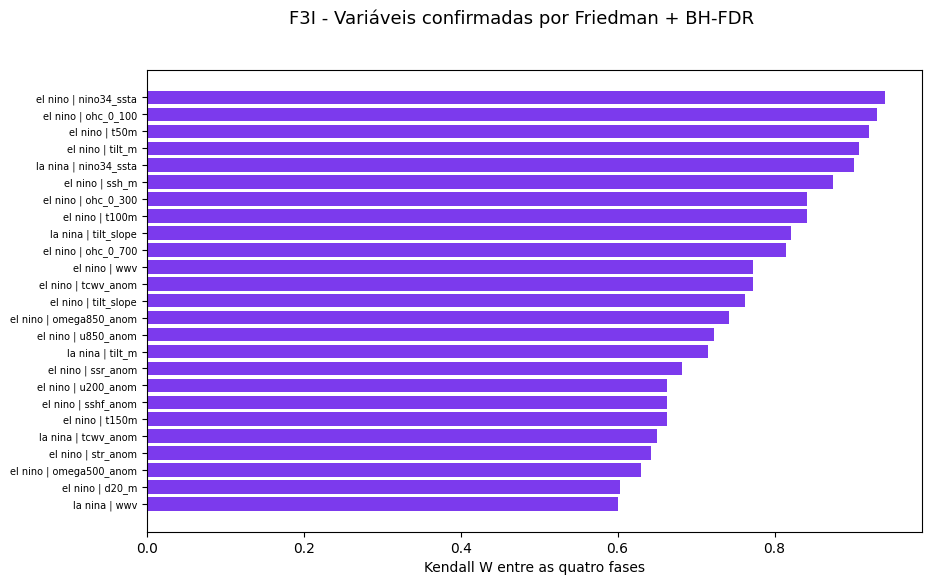

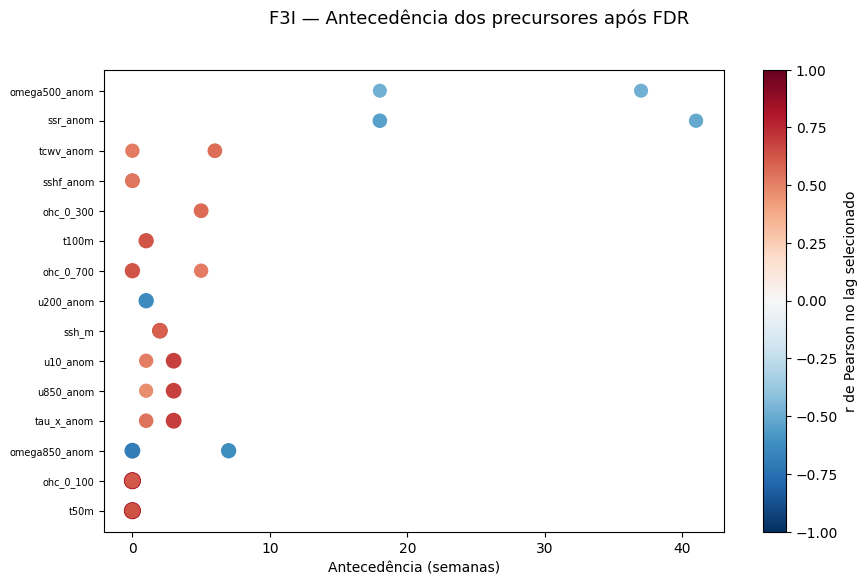

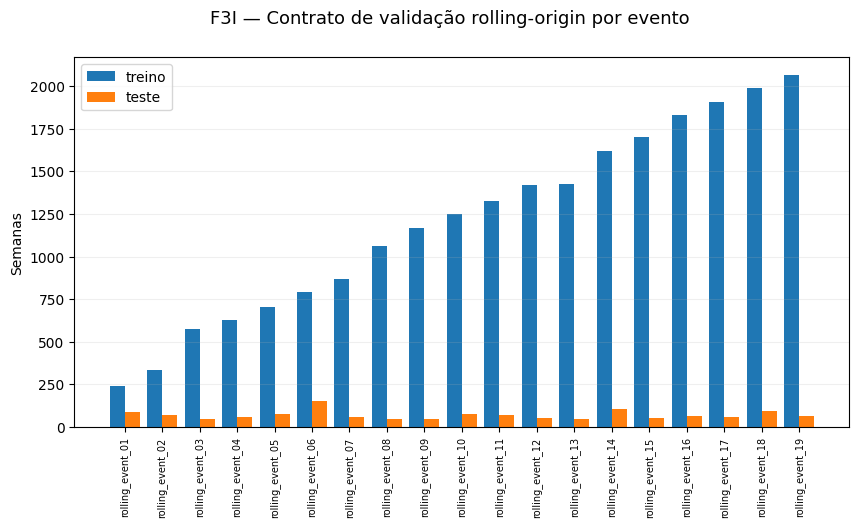

In [3]:
table_names=['phase3_best_lags_fdr.csv', 'phase3_discriminantes_por_periodo.csv', 'phase3_rolling_origin_targets.csv', 'phase3_rolling_origin_folds.csv']
base = STATS/'pilots/quick' if MODE == 'smoke' else STATS
inventory=[]
for name in table_names:
    path=base/name
    inventory.append({'table':name,'exists':path.exists(),'manifest':path.with_suffix(path.suffix+'.manifest.json').exists()})
display(pd.DataFrame(inventory))
for name in table_names:
    path=base/name
    if path.exists():
        print(name); display(pd.read_csv(path).head(30))

sys.path.insert(0, str(ROOT/'scripts'))
from render_phase3_semantic_summaries import render_block
render_block('I')


## Interpretação permitida

`diagnostico_retrospectivo` descreve gênese/crescimento/faixa de pico/decaimento após o evento. `rolling_origin_operacional` mede previsão. Resultados alinhados ao pico conhecido não são hindcasts operacionais.


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Timmermann, A., et al. (2018). El Niño-Southern Oscillation complexity. *Nature*, 559, 535-545. https://doi.org/10.1038/s41586-018-0252-6
2. Cai, W., et al. (2020). Climate impacts of ENSO on South America. *Nat. Rev. Earth Environ.*, 1, 215-231. https://doi.org/10.1038/s43017-020-0040-3
3. Cawley, G. C., & Talbot, N. L. C. (2010). On Over-fitting in Model Selection... *JMLR*, 11, 2079-2107. https://www.jmlr.org/papers/v11/cawley10a.html

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.